Predicting and Classifying Learning Outcomes with ML

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.discriminant_analysis import StandardScaler


In [2]:
education_df = pd.read_csv("dataset_Final_Project_CSML.csv")
education_df.head() 
education_df.info()
education_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State                  153 non-null    object 
 1   Total expenditures     153 non-null    int64  
 2   student_teacher_ratio  153 non-null    float64
 3   per-pupil_spending     153 non-null    int64  
 4   Median_Income          153 non-null    object 
 5   Poverty Rate           153 non-null    float64
 6   Urbanization           153 non-null    float64
 7   Teacher_Salary         153 non-null    int64  
 8   Graduation_Rate        153 non-null    float64
 9   Year                   153 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 12.1+ KB


,Total expenditures,student_teacher_ratio,per-pupil_spending,Poverty Rate,Urbanization,Teacher_Salary,Graduation_Rate,Year
count,1.530000e+02,153.000000,153.000000,153.000000,153.000000,1.530000e+02,153.000000,153.00000
mean,1.134181e+10,15.730719,10770.810458,13.019608,73.110458,2.919782e+09,79.045752,2010.00000
std,1.469729e+10,2.779916,4401.762975,3.259804,15.030290,3.570481e+09,8.515388,8.19178
min,7.247356e+08,10.800000,4378.000000,6.500000,35.100000,2.586780e+08,54.500000,2000.00000
25%,2.689838e+09,13.900000,7425.000000,10.500000,63.600000,7.846006e+08,75.200000,2000.00000
50%,6.924814e+09,15.100000,9846.000000,12.500000,73.100000,1.806721e+09,80.800000,2010.00000
75%,1.305497e+10,17.000000,13023.000000,15.300000,86.300000,3.341705e+09,84.900000,2020.00000
max,9.898620e+10,23.800000,26441.000000,22.400000,100.000000,2.067122e+10,92.100000,2020.00000


(153, 10)


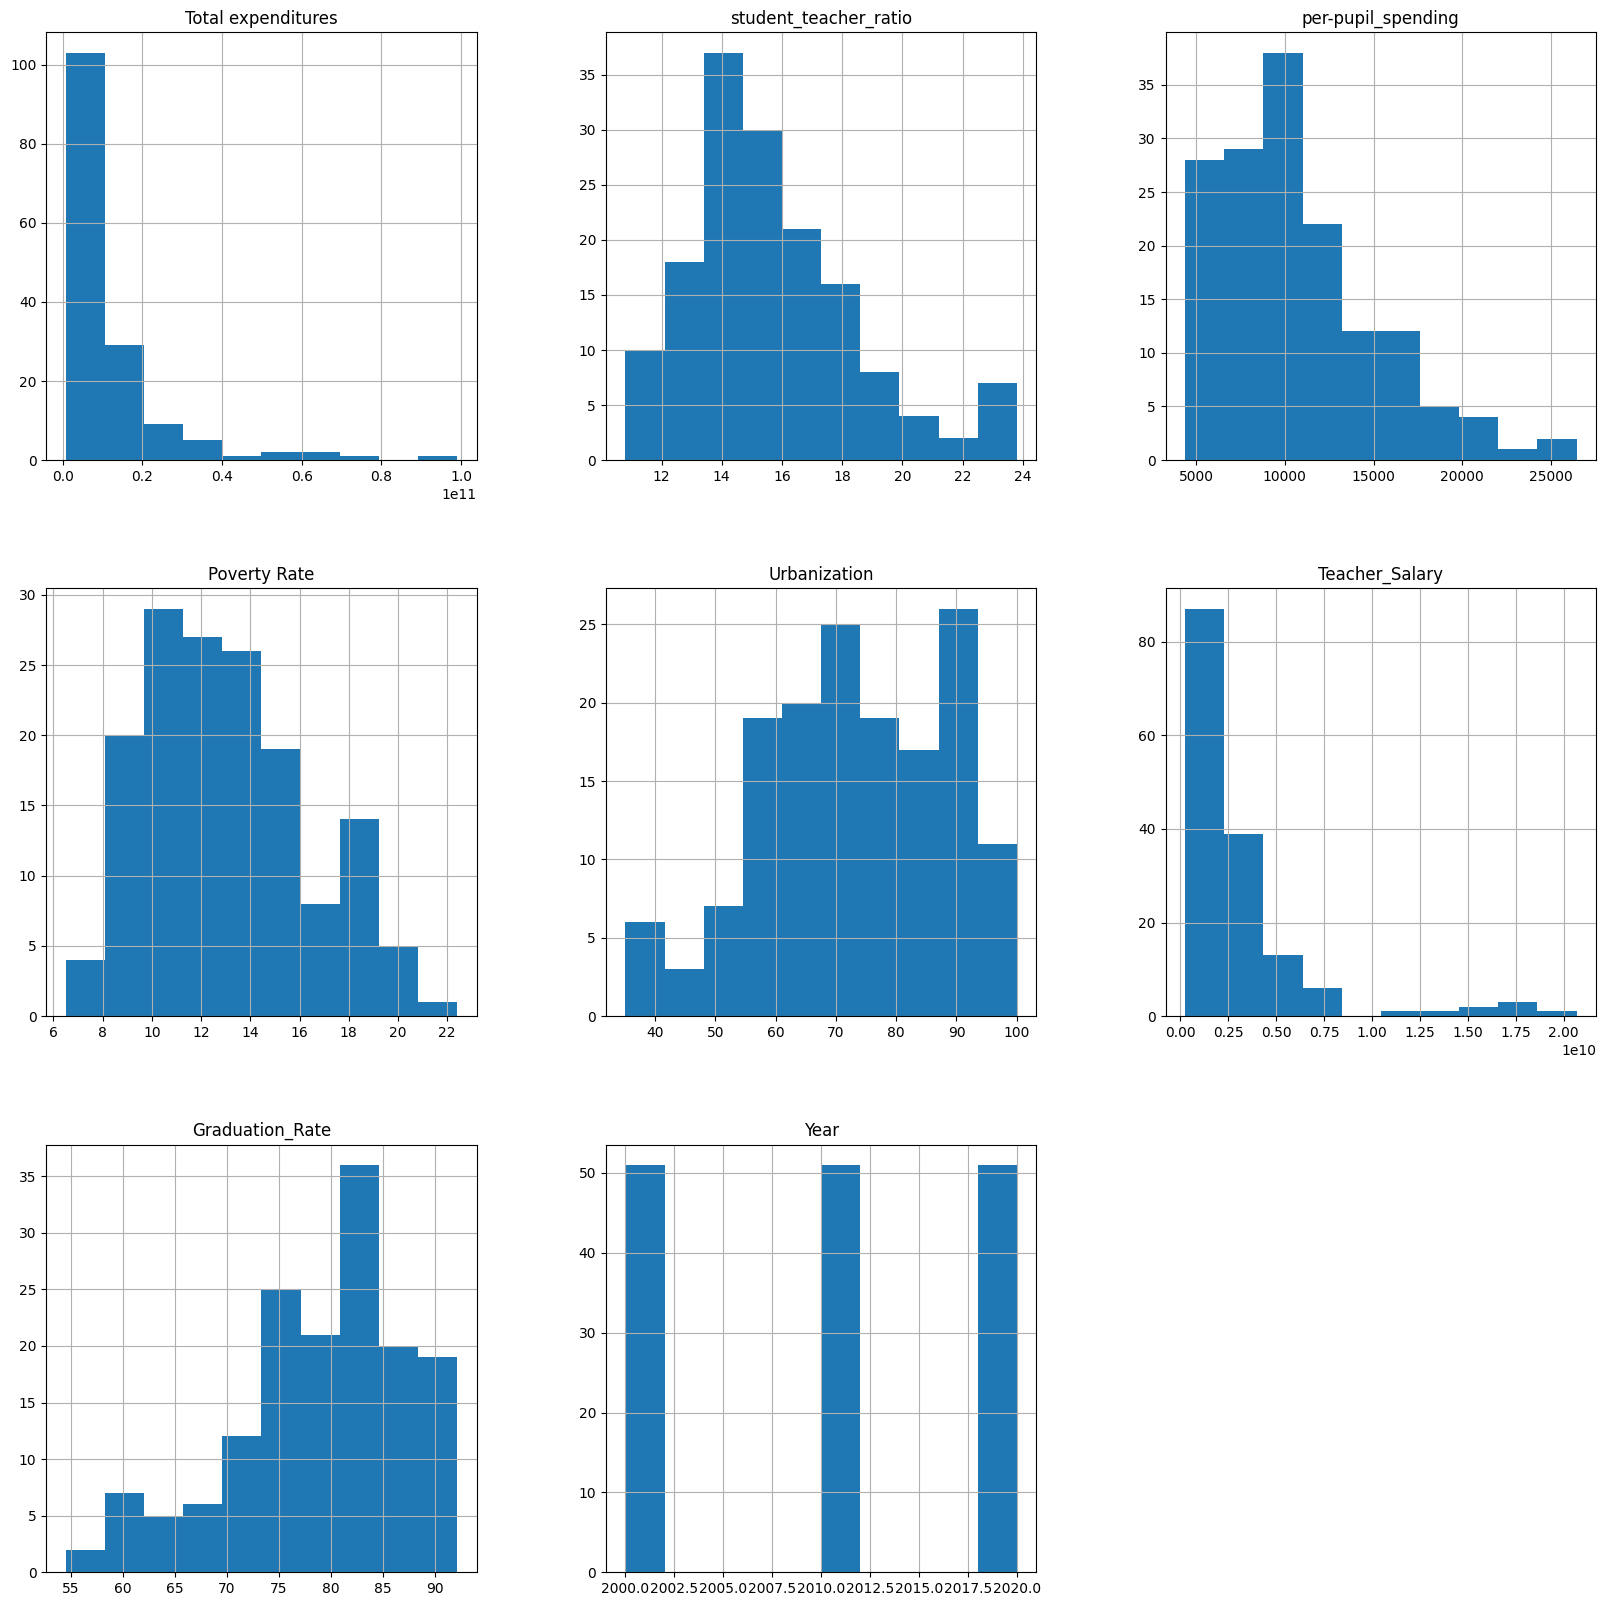

In [3]:
print(education_df.shape)
education_df.hist(figsize=(20, 20))
plt.show()

In [5]:
df_encoded = pd.get_dummies(education_df, columns=['State'], prefix='State')

# 4. Save the new dataset
output_filename = "combined_encoded_education_data.csv"
df_encoded.to_csv(output_filename, index=False)

# Optional: View the new shape and first few rows
print(f"New dataset shape: {df_encoded.shape}")
print(df_encoded.head())

New dataset shape: (153, 60)
   Total expenditures  student_teacher_ratio  per-pupil_spending  \
0          4935621221                   15.4                5638   
1          1375232700                   16.9                8806   
2          5588398292                   19.8                4999   
3          2628202265                   14.1                5277   
4         44459535249                   20.6                6314   

  Median_Income  Poverty Rate  Urbanization  Teacher_Salary  Graduation_Rate  \
0        44,667          16.1          55.4      1880267638             64.1   
1        67,483           9.4          65.6       450803336             66.7   
2        53,072          13.9          88.2      1787356212             63.6   
3        42,111          15.8          52.5      1084819850             74.6   
4        62,147          14.2          94.4     17023740804             71.7   

   Year  State_Alabama  ...  State_South Dakota  State_Tennessee  State_Texas  \


In [6]:
num_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_encoded[num_cols].corr()

# 7. Create and save the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Educational Features (2000-2020 Combined)")
plt.tight_layout()
plt.savefig("fixed_correlation_heatmap.png")
plt.close()

In [11]:
state_cols = [col for col in df_encoded.columns if col.startswith('State_')]
non_state_cols = [col for col in df_encoded.columns if col not in state_cols]

# Clean thousand separators in object columns, then convert non-State columns to float64
for col in non_state_cols:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = (
            df_encoded[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

df_encoded[non_state_cols] = df_encoded[non_state_cols].astype('float64')

cols_to_exclude = ['Year', 'Graduation_Rate'] + state_cols

# 3. Create a list of the continuous numerical columns we actually want to scale
cols_to_scale = [col for col in df_encoded.select_dtypes(include=['float64', 'int64']).columns if col not in cols_to_exclude]

# 4. Initialize the StandardScaler
scaler = StandardScaler()

# 5. Fit the scaler to the selected columns and transform them
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# 6. Save the final preprocessed dataset
df_encoded.to_csv("final_preprocessed_education_data.csv", index=False)

# Optional: Print to verify the results
print(df_encoded[cols_to_scale].head())

   Total expenditures  student_teacher_ratio  per-pupil_spending  \
0           -0.437307              -0.119358           -1.169910   
1           -0.680351               0.421999           -0.447835   
2           -0.392747               1.468622           -1.315556   
3           -0.594819              -0.588534           -1.252192   
4            2.260722               1.757345           -1.015831   

   Median_Income  Poverty Rate  Urbanization  Teacher_Salary  
0      -1.055766      0.948066     -1.182187       -0.292097  
1       0.781957     -1.114022     -0.501329       -0.693768  
2      -0.378782      0.270962      1.007239       -0.318205  
3      -1.261639      0.855733     -1.375765       -0.515613  
4       0.352167      0.363294      1.421094        3.963129  


In [18]:
lm = LinearRegression()

cols_Exclude = ['Graduation_Rate'] + [col for col in df_encoded.columns if col.startswith('State_')]

X = df_encoded[[col for col in df_encoded.columns if col not in cols_Exclude]]
y = df_encoded['Graduation_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_error


predicts = lm.predict(X_test)

print("""
        Mean Absolute Error: {}
        Root Mean Squared Error: {}
        R2 Score: {}
     """.format(
        mean_absolute_error(y_test,predicts),
        np.sqrt(metrics.mean_squared_error(y_test, predicts)),
        r2_score(y_test,predicts),
        ))


        Mean Absolute Error: 4.00913911710684
        Root Mean Squared Error: 5.738401375590836
        R2 Score: 0.627022298934673
     


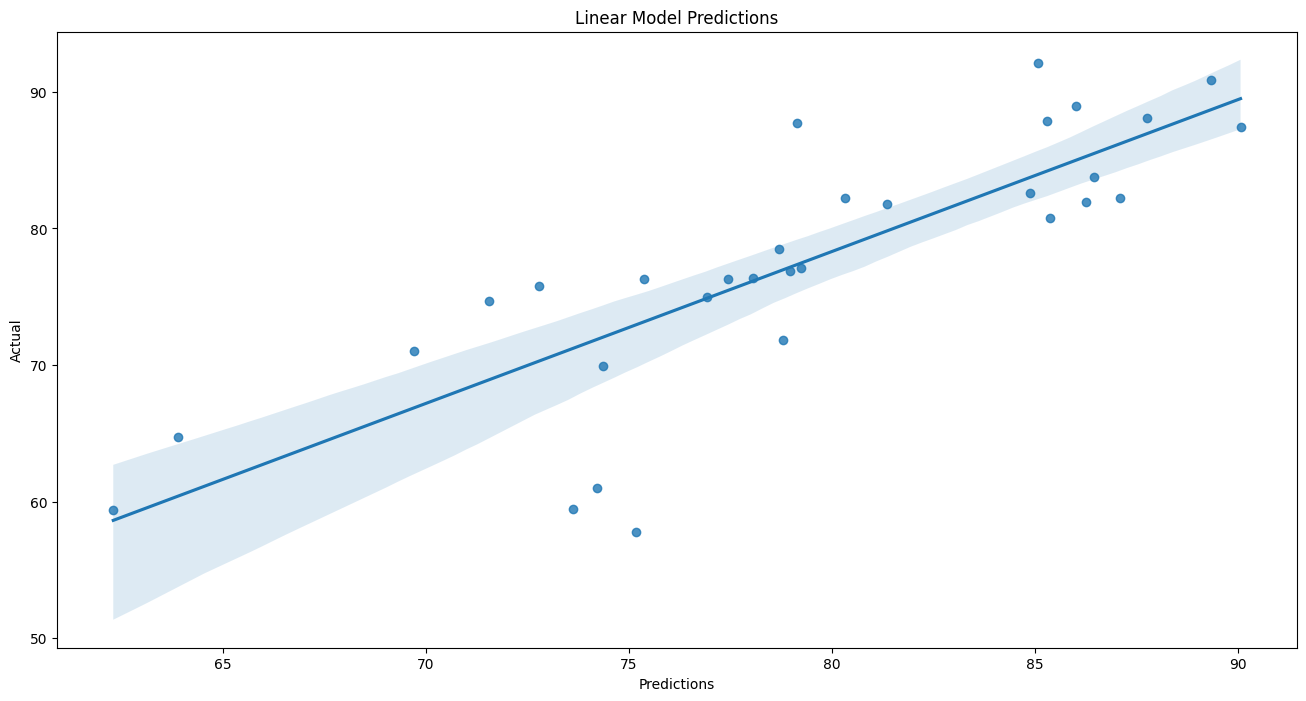

In [20]:
plt.figure(figsize=(16,8))
sns.regplot(x=predicts, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Linear Model Predictions")
plt.grid(False)
plt.show()

In [21]:
from sklearn import linear_model

clf = linear_model.BayesianRidge()
clf.fit(X_train, y_train)

,"max_iter max_iter: int, default=300Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion... versionchanged:: 1.3",300
,"tol tol: float, default=1e-3Stop the algorithm if w has converged.",0.001
,"alpha_1 alpha_1: float, default=1e-6Hyper-parameter : shape parameter for the Gamma distribution priorover the alpha parameter.",1e-06
,"alpha_2 alpha_2: float, default=1e-6Hyper-parameter : inverse scale parameter (rate parameter) for theGamma distribution prior over the alpha parameter.",1e-06
,"lambda_1 lambda_1: float, default=1e-6Hyper-parameter : shape parameter for the Gamma distribution priorover the lambda parameter.",1e-06
,"lambda_2 lambda_2: float, default=1e-6Hyper-parameter : inverse scale parameter (rate parameter) for theGamma distribution prior over the lambda parameter.",1e-06
,"alpha_init alpha_init: float, default=NoneInitial value for alpha (precision of the noise).If not set, alpha_init is 1/Var(y)... versionadded:: 0.22",None
,"lambda_init lambda_init: float, default=NoneInitial value for lambda (precision of the weights).If not set, lambda_init is 1... versionadded:: 0.22",None
,"compute_score compute_score: bool, default=FalseIf True, compute the log marginal likelihood at each iteration of theoptimization.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model.The intercept is not treated as a probabilistic parameterand thus has no associated variance. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [24]:
predicts = clf.predict(X_test)

print("""
        Mean Absolute Error: {}
        Root Mean Squared Error: {}
        R2 Score: {}
     """.format(
        mean_absolute_error(y_test,predicts),
        np.sqrt(metrics.mean_squared_error(y_test, predicts)),
        r2_score(y_test,predicts),
        ))


        Mean Absolute Error: 3.987948978111921
        Root Mean Squared Error: 5.682403059776328
        R2 Score: 0.6342662029038282
     


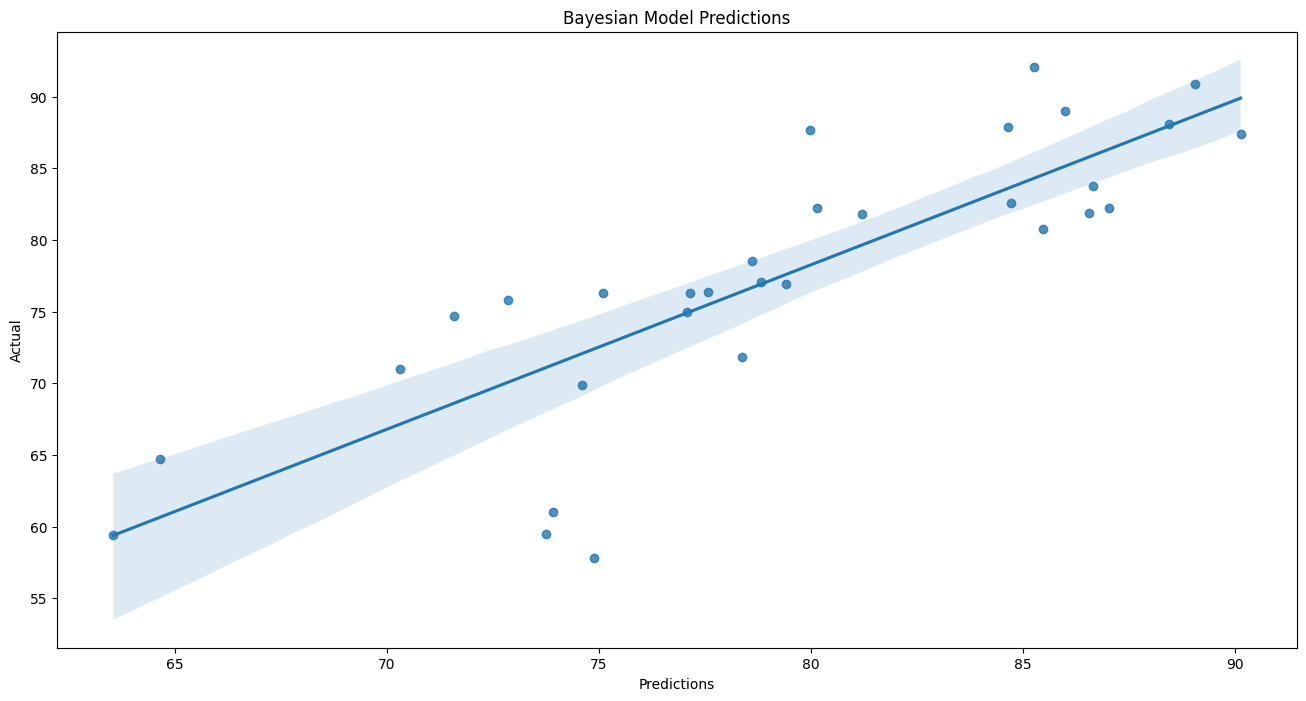

In [26]:
plt.figure(figsize=(16,8))
sns.regplot(x=predicts, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Bayesian Model Predictions")
plt.grid(False)
plt.show()